# Análisis Exploratorio de Datos
Dataset de señales EMG para clasificación de 4 gestos de la mano:
- 0 --> Piedra
- 1 --> Tijera
- 2 --> Papel
- 3 --> Ok

64 columnas 8 canales EMG x 8 intentes de tiempo por ventana.

## 1. Imports y config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings


warnings.filterwarnings('ignore')

np.random.seed(42)

VER_PLOTS=True

sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
PALETTE = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
NOMBRES = {0: 'Piedra', 1: 'Tijera', 2: 'Papel', 3: 'Ok'}
COLORES_CLASE = {i: PALETTE[i] for i in range(4)}

## 2. Carga dataset

In [2]:
df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)

dfs_por_clase = {0: df_0, 1: df_1, 2: df_2, 3: df_3}

df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

# Se cambia nombre de las columnas
sensor_cols = [f'S{i}' for i in range(64)]
df.columns = sensor_cols + ['label']
for k in dfs_por_clase:
    dfs_por_clase[k].columns = sensor_cols + ['label']

X = df[sensor_cols]
y = df['label']

## 3. Ver si hay nulos y demás

In [3]:
print(f'Número de filas: {len(y)}')
print(f'Columnas: {df.shape[1]-1}')
print(f'Clases: {y.nunique()} ({list(NOMBRES.values())})')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'Rango de valores: [{X.values.min()}, {X.values.max()}]')
print(f'Dtype sensores: {X.dtypes.unique()[0]}')


Número de filas: 11678
Columnas: 64
Clases: 4 (['Piedra', 'Tijera', 'Papel', 'Ok'])
Valores nulos: 0
Rango de valores: [-128.0, 127.0]
Dtype sensores: float64


In [4]:
X.iloc[:,:8].describe().round(2)

,S0,S1,S2,S3,S4,S5,S6,S7
count,11678.00,11678.00,11678.00,11678.00,11678.00,11678.00,11678.00,11678.00
mean,-0.52,-0.73,-0.74,-0.73,-0.16,-0.55,-1.27,-0.66
std,18.57,11.77,4.99,7.44,17.85,25.81,25.09,15.41
min,-116.00,-104.00,-33.00,-75.00,-121.00,-122.00,-128.00,-128.00
25%,-9.00,-4.00,-3.00,-4.00,-10.00,-15.00,-6.00,-8.00
50%,-1.00,-1.00,-1.00,-1.00,0.00,-1.00,-1.00,-1.00
75%,7.00,3.00,2.00,3.00,10.00,13.00,4.00,6.00
max,111.00,90.00,34.00,55.00,92.00,127.00,127.00,126.00


## 4. Distribución de clases

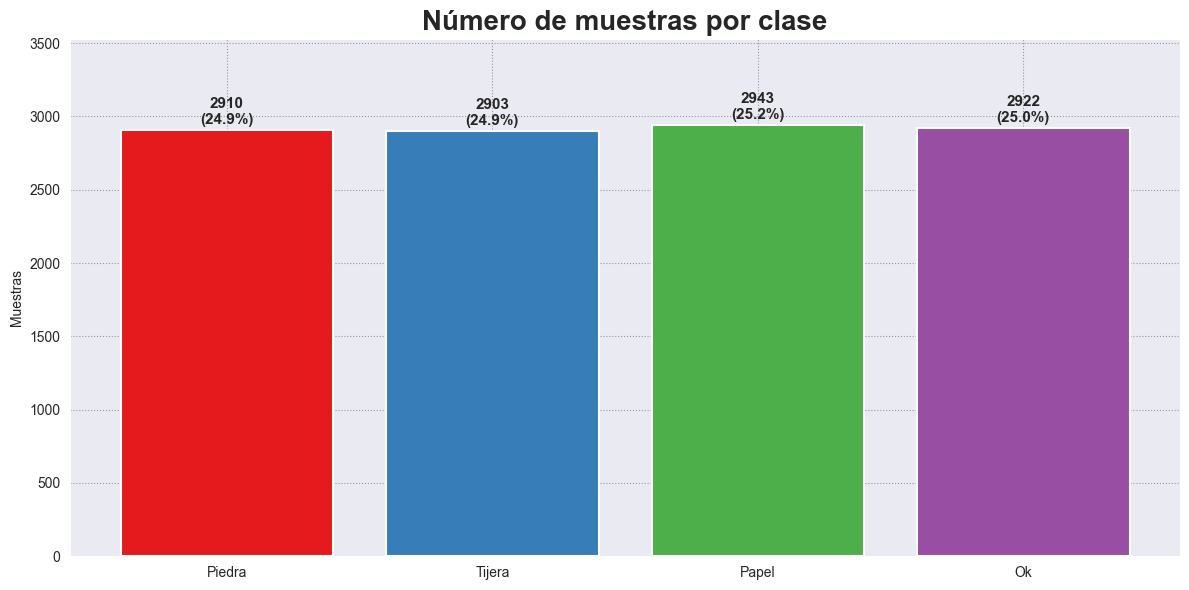

In [5]:
conteos = y.value_counts().sort_index()
pcts = conteos / len(y) * 100

fig = plt.figure(figsize=(12, 6))

bars = plt.bar(
    [NOMBRES[i] for i in conteos.index],
    conteos.values,
    color=PALETTE,
    edgecolor='white',
    linewidth=1.5
)
for bar, pct, cnt in zip(bars, pcts.values, conteos.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{cnt}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
plt.title('Número de muestras por clase', fontsize=20, fontweight='bold')
plt.ylabel('Muestras')
plt.ylim(0, max(conteos.values) * 1.2)
plt.tight_layout()
plt.savefig('plots/01_distribucion_clases.png', dpi=300, bbox_inches='tight')
plt.show() if VER_PLOTS else plt.close()

## 5. Señales EMG crudas por clase


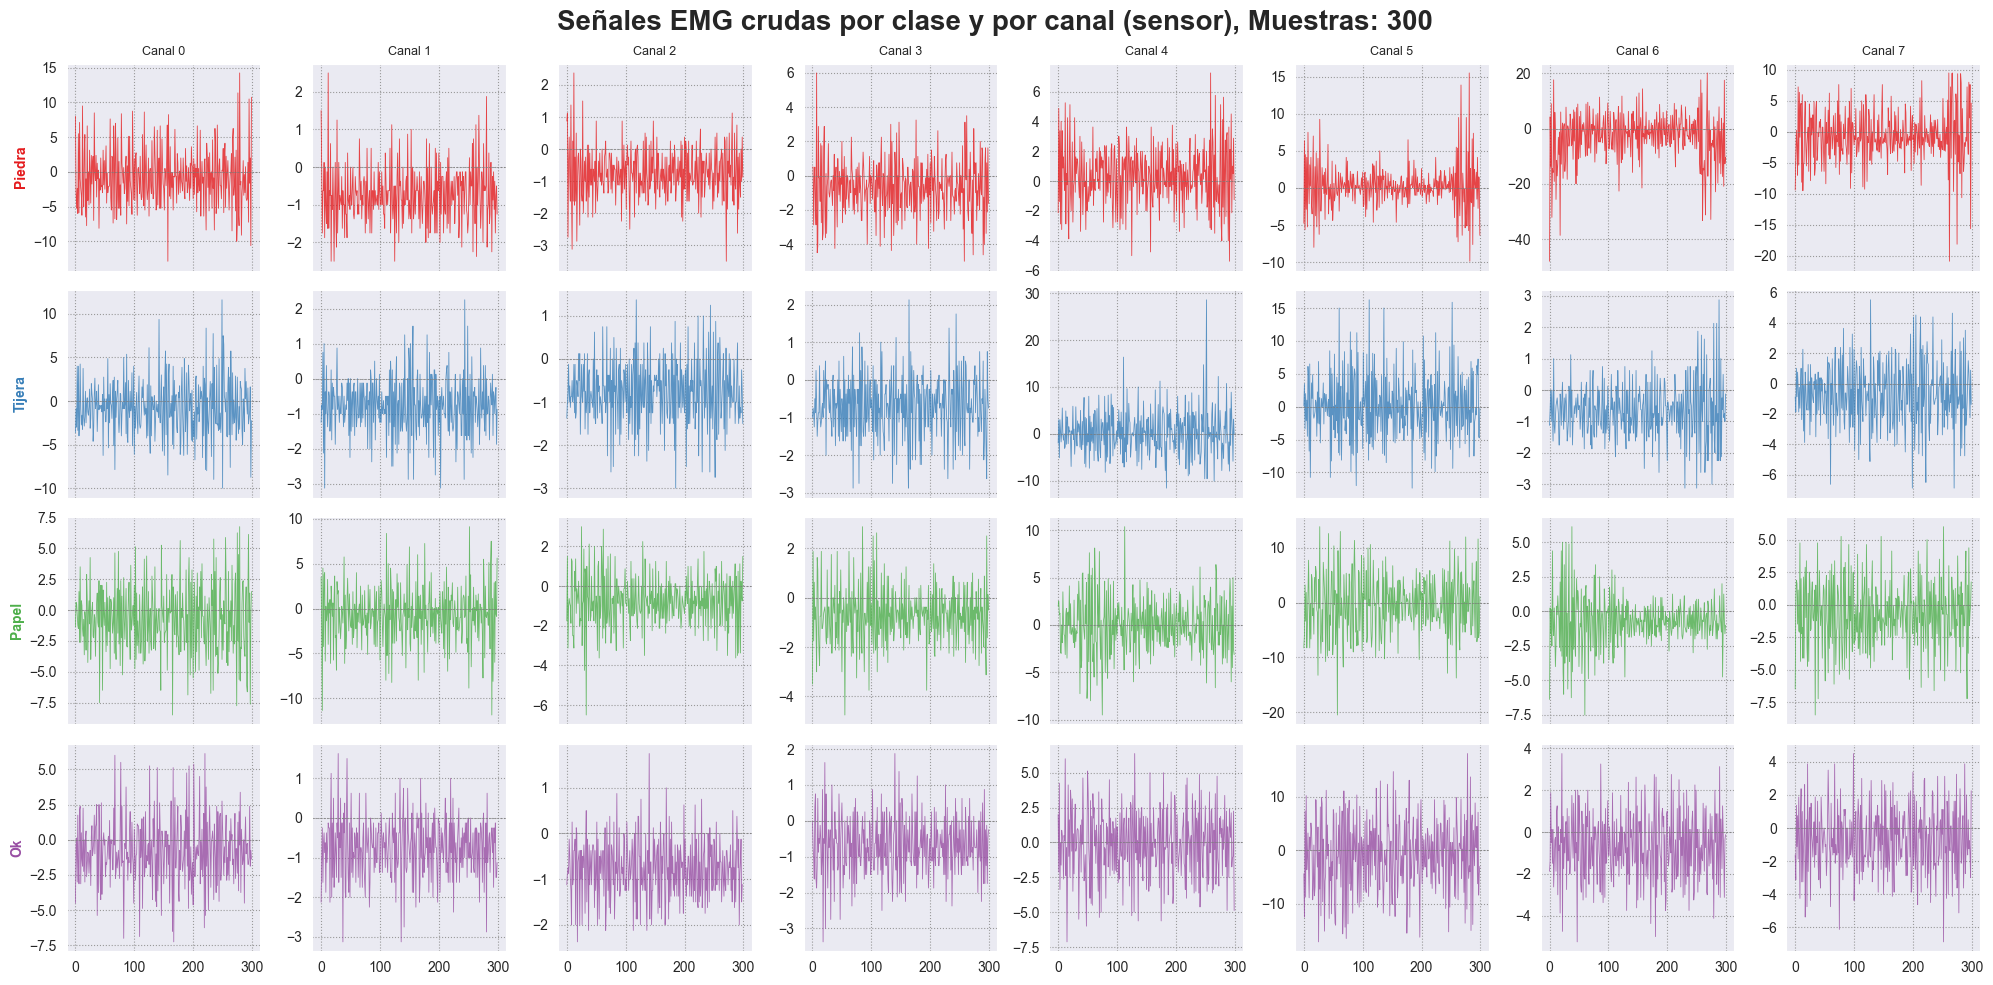

In [6]:
N_muestras=300
fig, axes = plt.subplots(4,8,figsize=(20,10),sharex=True)

plt.suptitle(f'Señales EMG crudas por clase y por canal (sensor), Muestras: {N_muestras}', fontsize=20, fontweight='bold')

for clase in range(4):
    subset = dfs_por_clase[clase][sensor_cols].values[:N_muestras] # 300 muestras de la clase
    for canal in range(8):
        indices_canal = [canal + 8*t for t in range(8)] # pilla las columnas del mismo sensor en la fila para hacerle la media
        signal = subset[:, indices_canal].mean(axis=1)
        axes[clase, canal].plot(signal, color=PALETTE[clase], linewidth=0.6, alpha=0.8)
        axes[clase, canal].axhline(0, color='gray', linewidth=0.5, linestyle='--')

        if clase == 0:
            axes[clase, canal].set_title(f'Canal {canal}', fontsize=9)

        if canal == 0:
            axes[clase, canal].set_ylabel(NOMBRES[clase], fontsize=10, fontweight='bold', color=PALETTE[clase])




plt.tight_layout()
plt.savefig('plots/02_señales_crudas.png', dpi=300, bbox_inches='tight')
plt.show() if VER_PLOTS else plt.close()


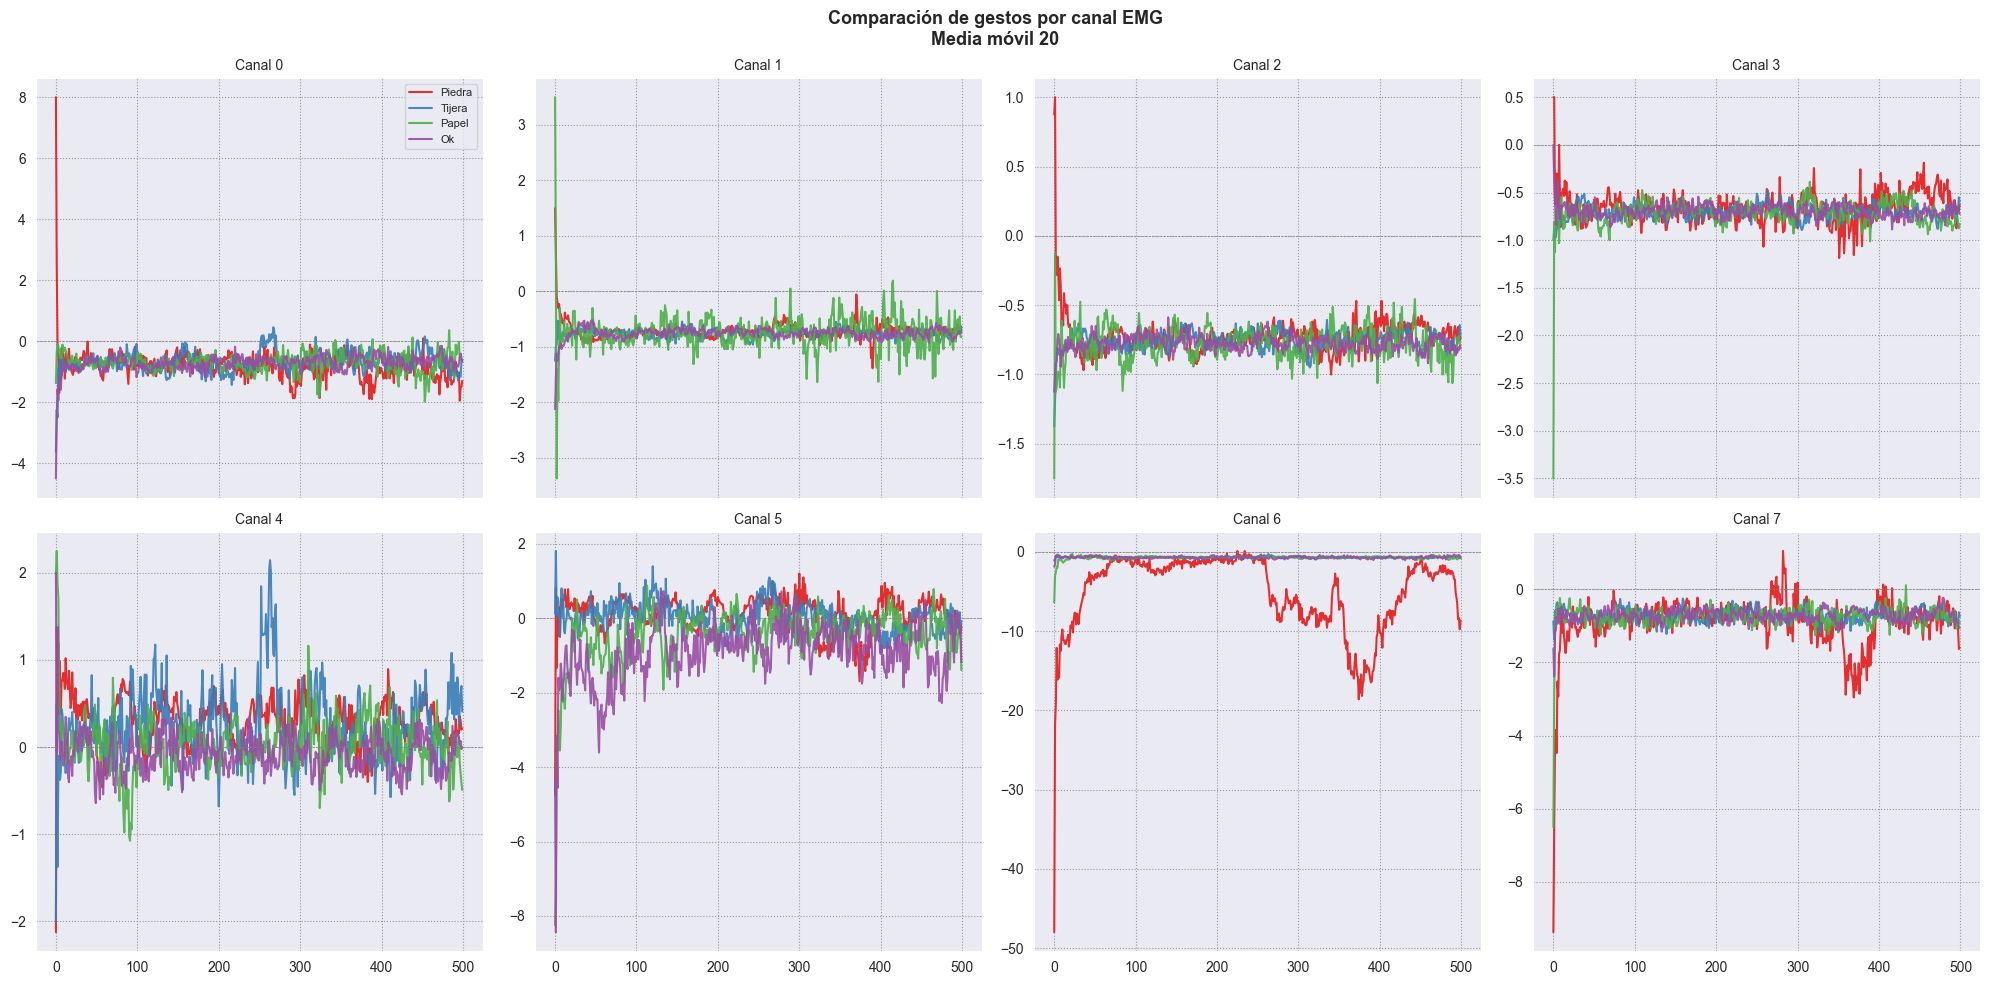

In [7]:
fig,axes=plt.subplots(2,4,figsize=(20,10),sharex=True)
ventana=20
N=500

fig.suptitle(f'Comparación de gestos por canal EMG\nMedia móvil {ventana}', fontsize=13, fontweight='bold')
for canal in range(8):
    ax  = axes[canal//4,canal%4]
    indices_canal = [canal + 8*t for t in range(8)]
    for clase in range(4):
        signal=dfs_por_clase[clase][sensor_cols].values[:N, indices_canal].mean(axis=1) # hace la media de las mismas señales de la fila con una muestra de 500, eso para cada clase para comparar
        ma = pd.Series(signal).rolling(ventana, min_periods=1).mean().values
        ax.plot(ma, color=PALETTE[clase], label=NOMBRES[clase], linewidth=1.5, alpha=0.9)


    ax.set_title(f'Canal {canal}', fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    if canal == 0:
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('plots/03_señales_overlay.png', dpi=300, bbox_inches='tight')
plt.show() if VER_PLOTS else plt.close()


## 6. Estadísticos por clase: heatmap de medias

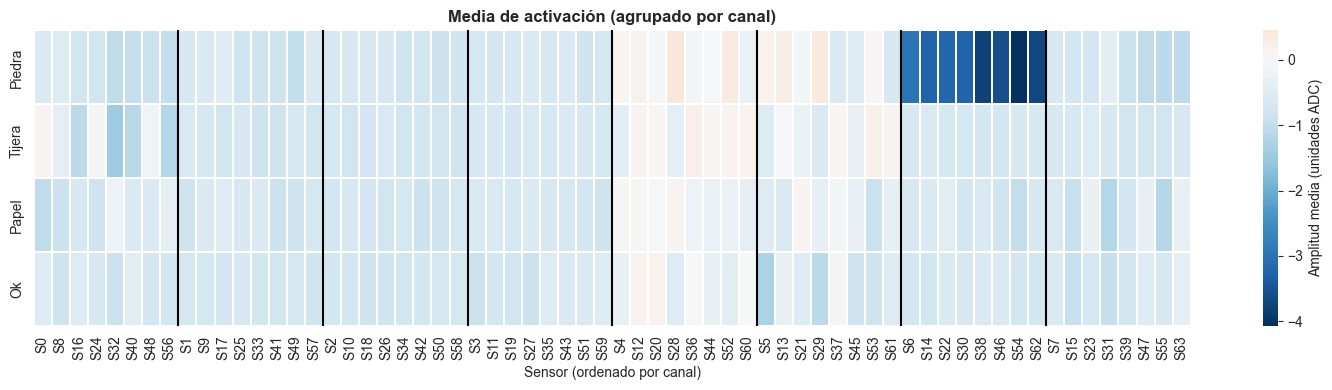

In [8]:
medias_por_clase = df.groupby('label')[sensor_cols].mean()
medias_por_clase.index = [NOMBRES[i] for i in medias_por_clase.index] # poner como índice piedra, ok, etc

orden_por_canal = [canal + 8*t for canal in range(8) for t in range(8)]
cols_ordenadas = [sensor_cols[i] for i in orden_por_canal]
plt.figure(figsize=(15,4))
sns.heatmap(
    medias_por_clase[cols_ordenadas],
    cmap='RdBu_r',
    center=0,
    linewidths=0.1,
    cbar_kws={'label': 'Amplitud media (unidades ADC)'}
)
plt.title('Media de activación (agrupado por canal)', fontsize=12, fontweight='bold')
plt.xlabel('Sensor (ordenado por canal)')

for c in range(1, 8):
    plt.axvline(c * 8, color='black', linewidth=1.5)

plt.tight_layout()
plt.savefig('plots/04_heatmap_medias.png', dpi=300, bbox_inches='tight')
plt.show() if VER_PLOTS else plt.close()
